# Halo Occupation Distribution (HOD) with OpenCosmo

In this tutorial, we compute the Halo Occupation Distribution (HOD) for hydrodynamic simulations from the SCIDAC suite.

The HOD describes the average number of galaxies hosted by halos as a function of halo mass:

\[
\langle N_{\mathrm{gal}} \mid M_{\mathrm{halo}} \rangle
\]

We will:
- Load halo and galaxy data
- Select cluster-scale halos
- Count galaxies per halo
- Compute and plot the HOD

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import opencosmo as oc
import astropy.units as u

## Load dataset

We begin by loading the dataset using OpenCosmo.

In [9]:
# Example placeholders — replace with your actual files
halo_file = "haloproperties/m000p-567.haloproperties.hdf5"
gal_file = "galaxyproperties/m000p-567.galaxyproperties.hdf5"

ds = oc.open(halo_file, gal_file, ignore_empty=False)
print(ds)

Collection of halos with galaxy_properties and halo_properties


## Inspect dataset structure

Each halo is represented as a structure containing:
- `halo_properties`
- `galaxy_properties`

In [10]:
for halo in ds.halos():
    print(halo.keys())
    break

dict_keys(['halo_properties'])


## Select cluster-scale halos

In [11]:
mass_cut = 5e13 * u.Msun
ds_filt = ds.filter(oc.col("fof_halo_mass") > mass_cut)

In [12]:
halo_masses = []
ngal_list = []

for halo in ds_filt.halos():
    mhalo = halo["halo_properties"]["fof_halo_mass"]
    ngal = len(halo["galaxy_properties"])
    
    halo_masses.append(mhalo.to_value(u.Msun))
    ngal_list.append(ngal)

In [13]:
halo_masses = np.array(halo_masses)
ngal_list = np.array(ngal_list)

In [14]:
print("Number of halos:", len(halo_masses))
print("Example Ngal values:", ngal_list[:10])

Number of halos: 165
Example Ngal values: [18 12 15 17 19 21 10 12 32 42]


## Compute the HOD

We bin halos in log mass and compute the mean number of galaxies per bin.

In [15]:
logM = np.log10(halo_masses)

nbins = 8
bins = np.linspace(logM.min(), logM.max(), nbins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

inds = np.digitize(logM, bins) - 1

mean_ngal = np.zeros(nbins)
std_ngal = np.zeros(nbins)
counts = np.zeros(nbins)

for i in range(nbins):
    mask = inds == i
    counts[i] = np.sum(mask)
    
    if counts[i] > 0:
        mean_ngal[i] = np.mean(ngal_list[mask])
        std_ngal[i] = np.std(ngal_list[mask])
    else:
        mean_ngal[i] = np.nan
        std_ngal[i] = np.nan

## Check bin populations

We inspect how many halos fall into each bin.

In [16]:
print("Counts per bin:", counts)

Counts per bin: [55. 45. 21. 20. 14.  7.  1.  1.]


## Plot the HOD

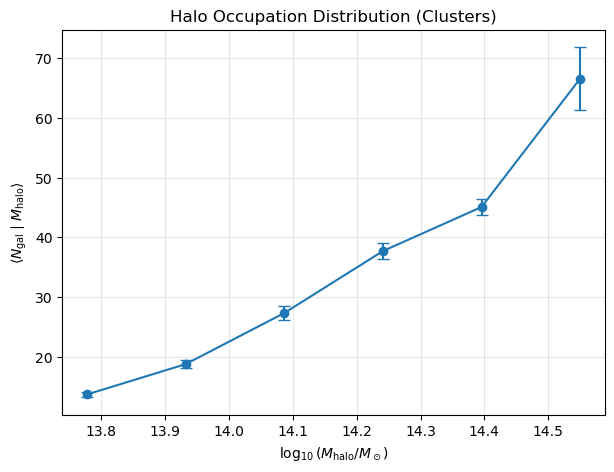

In [17]:
min_count = 5
valid = (counts >= min_count) & np.isfinite(mean_ngal)

plt.figure(figsize=(7,5))

plt.errorbar(
    bin_centers[valid],
    mean_ngal[valid],
    yerr=std_ngal[valid] / np.sqrt(counts[valid]),
    fmt='o-',
    capsize=4
)

plt.xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
plt.ylabel(r'$\langle N_{\rm gal} \mid M_{\rm halo} \rangle$')
plt.title("Halo Occupation Distribution (Clusters)")
plt.grid(True, alpha=0.3)

plt.show()

## Galaxy counts per halo

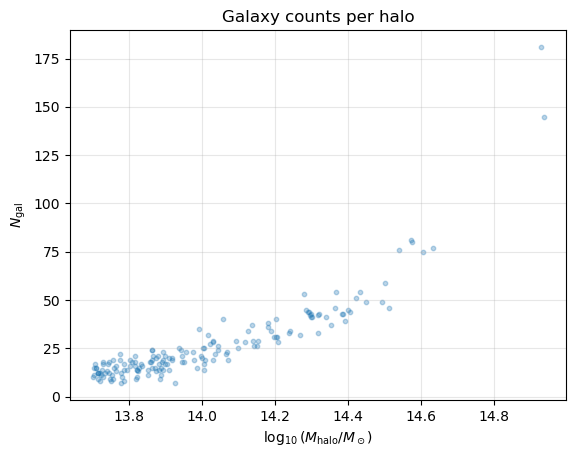

In [18]:
plt.scatter(logM, ngal_list, alpha=0.3, s=10)

plt.xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
plt.ylabel(r'$N_{\rm gal}$')
plt.title("Galaxy counts per halo")

plt.grid(True, alpha=0.3)
plt.show()

## Summary

In this tutorial, we:
- Loaded halo and galaxy data using OpenCosmo
- Selected cluster-scale halos
- Counted galaxies per halo
- Computed and visualized the Halo Occupation Distribution (HOD)

This workflow can be extended to compare galaxy populations across multiple simulations.